In [2]:
%pip install pandas transformers deepparse huggingface_hub matplotlib ipympl rdflib dask
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for i in range(torch.cuda.device_count()):
        print(f"  {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device('cuda')
elif torch.accelerator.is_available(): # Support other hardware accelators
    device = torch.accelerator.current_accelerator()
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')
print(f"Torch version: {torch.__version__}, Device: {device}")

Torch version: 2.10.0+xpu, Device: xpu


In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [5]:
from collections import OrderedDict
import pandas as pd
import json

COLS_TO_PREDICT = [
    "HouseNumber",
    "StreetName",
    "City",
    "State",
    "Country"
]
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv")
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv")

EXAMPLES = [
    ("Berlin, Alexanderplatz 1, 10178", 
     OrderedDict([("City" , "Berlin"), ("StreetName", "Alexanderplatz"), ("HouseNumber", "1")])),
    ("Braunschweig, Uferstr. 25", # From BZK open training set
     OrderedDict([("City", "Braunschweig"), ("StreetName", "Uferstr."), ("HouseNumber", "25")])),
    ("808 Westend Avenue, New York 25, N.Y.", # From BZK open training set
        OrderedDict([("StreetName", "Westend Avenue"), ("HouseNumber", "808"), 
        ("City", "New York"), ("State", "N.Y.")])),
]



In [6]:

from mllms import JsonDictPromptTemplate, JSONTuplesPromptTemplate


PROMPTS = [
    JsonDictPromptTemplate("Segment addresses into their components.\n"
    "Output only a JSON object with the following keys: " + ", ".join(COLS_TO_PREDICT) + ". "
    "Do not include fields that cannot be determined and do not try to guess their values. "
    "For example, if the address is simply \"Berlin\" then the field \"Country\" should be null. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n%(examples)s"
    "Now segment the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("Annotate address components with the respective types. "
    "Consider the component types: " + ", ".join(COLS_TO_PREDICT + ["Other"]) + ". "
    "Not all addresses will contain all component types and you must not guess the missing ones. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Output only a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),
]



for i, prompt in enumerate(PROMPTS):
    print(f"Prompt {i}:")
    print(prompt.template)
    print()

Prompt 0:
Segment addresses into their components.
Output only a JSON object with the following keys: HouseNumber, StreetName, City, State, Country. Do not include fields that cannot be determined and do not try to guess their values. For example, if the address is simply "Berlin" then the field "Country" should be null. Addresses will most times be written in german, meaning country and city names may be in german and the addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße" or its abbreviation "str." for street.
These terms may occur as a suffix to another word.
%(examples)sNow segment the following address:
%(address)s

Prompt 1:
Annotate address components with the respective types. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. Not all addresses will contain all component types and you must not guess the missing ones. Addresses will most times be written in german, meaning country and city names may be in german 

In [6]:
from deepparse_parser import DeepParseParser
from libpostal_client import LibpostalClient
from mllms import LlamaAddressParsingModel, FixedExamples, ZeroShot
from itertools import combinations
import time
from pathlib import Path
from utils import compare_preds

model_configs = [
    {
        "name" : "libpostal",
        "factory": LibpostalClient,
        "cleanup": lambda client: client.close(),
    },
    {
        "name" : "libpostal-expanded",
        "factory": LibpostalClient,
        "factory_kargs" : {"expand_before_parsing": True},
        "cleanup": lambda client: client.close(),
    },
    {
        "name" : "deepparse-bpemb",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "device": device}
    },
    {
        "name" : "deepparse-fasttext",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "device": device}
    },
    {
        "name" : "deepparse-bpemb-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "attention_mechanism": True, "device": device}
    },
    {
        "name" : "deepparse-fasttext-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "attention_mechanism": True, "device": device}
    }
]

LLAMA_MODELS = [
    ("Llama-3.2-1B", "meta-llama/Llama-3.2-1B-Instruct"),
    ("Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct")
]

example_strategies = [
    ("0shot", ZeroShot())
]

for nshots in [1, 2]:
    for example_indices in combinations(range(len(EXAMPLES)), nshots):
        example_strategies.append((
             f"fixed{nshots}shot-ex{''.join(str(i) for i in example_indices)}", 
             FixedExamples([EXAMPLES[i] for i in example_indices])
        ))

example_strategies.append(("fixed3shot", FixedExamples(EXAMPLES)))

n_shot_model_configs = []

for example_strategy_id, example_strategy in example_strategies:
    for model_id, model_name in LLAMA_MODELS:
        for prompt_id, prompt in enumerate(PROMPTS):
                config_name = f"{model_id}-prompt{prompt_id}-{example_strategy_id}"
                n_shot_model_configs.append({
                    "name": config_name,
                    "factory": LlamaAddressParsingModel,
                    "factory_kargs" : {
                        "model_name": model_name,
                        "prompt": prompt,
                        "example_strategy": example_strategy,
                        "device": device
                    }
                })

model_configs.extend(config for config in n_shot_model_configs if config["name"].endswith("3shot"))

for config in model_configs:
    print(f"Model config: {repr(config)}")


Model config: {'name': 'libpostal', 'factory': <class 'libpostal_client.LibpostalClient'>, 'cleanup': <function <lambda> at 0x000001B692E47D80>}
Model config: {'name': 'libpostal-expanded', 'factory': <class 'libpostal_client.LibpostalClient'>, 'factory_kargs': {'expand_before_parsing': True}, 'cleanup': <function <lambda> at 0x000001B70989D760>}
Model config: {'name': 'deepparse-bpemb', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'device': device(type='xpu')}}
Model config: {'name': 'deepparse-fasttext', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'fasttext', 'device': device(type='xpu')}}
Model config: {'name': 'deepparse-bpemb-attention', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'attention_mechanism': True, 'device': device(type='xpu')}}
Model config: {'name': 'deepparse-fasttext-attention', 'factory': <class 'deepparse_parser.DeepPars

c:\Users\rpa\Documents\wiedergutmachung\bzk-post-processing\.conda\Lib\site-packages\pymagnitudelight\framework\repoze\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [8]:


def eval(dataset, configs, cols_to_predict, pred_cache_path=None):
    if pred_cache_path is not None:
        pred_cache_path = Path(pred_cache_path)
    if pred_cache_path is None or not pred_cache_path.exists():
        cached_preds = {}
    else:
        print(f"Loading cached predictions...")
        with open(pred_cache_path, "r") as f:
            cached_preds = json.load(f)
    
    preds_per_config = []
    model_results = []

    for config in configs:
        config_name = config["name"]
        if config_name in cached_preds:
            print(f"Using cached predictions for model {config_name}... To avoid this delete or rename the file {pred_cache_path} or delete the entry for {config_name} inside it.")
            preds = cached_preds[config_name]["preds"]
            deltatime = cached_preds[config_name]["deltatime"]
        else:
            print(f"Loading model {config_name}...")
            pargs = config.get("factory_pargs", [])
            kargs = config.get("factory_kargs", {})
            model = config["factory"](*pargs, **kargs)
            print(f"Segmenting addresses...")
            start = time.monotonic()
            preds = model.parse_addresses(dataset["FullAddress"].tolist())
            deltatime = time.monotonic() - start
            if "cleanup" in config:
                print("Cleaning up model resources...")
                config["cleanup"](model)
            print("Parsing model responses...")
            if pred_cache_path is not None:
                cached_preds[config_name] = {
                    "preds": preds,
                    "deltatime": deltatime
                }
        preds_df = pd.DataFrame(preds)
        preds_per_config.append(preds_df)
        print("Computing metrics...")
        metrics = compare_preds(preds_df, dataset[cols_to_predict], target_columns=cols_to_predict)
        metrics["deltatime"] = deltatime
        metrics["rate"] = len(dataset) / metrics["deltatime"]
        metrics["error"] = preds_df["error"].notna().sum() if "error" in preds_df.columns else 0
        metrics["errorRate"] = metrics["error"] / len(dataset)
        preds_df["config_name"] = config_name
        preds_df["FullAddress"] = dataset["FullAddress"]

        model_results.append(metrics)
        print(f"Results for model {config_name}: {metrics}")

    if pred_cache_path is not None:
        with open(pred_cache_path, "w") as f:
            json.dump(cached_preds, f)

    preds_per_config_df = pd.concat(preds_per_config)
    default_cols = ["config_name", "FullAddress"] + cols_to_predict
    new_order = default_cols + [col for col in preds_per_config_df.columns if col not in default_cols]
    preds_per_config_df = preds_per_config_df[new_order]

    results_df = pd.DataFrame(model_results, index = [config["name"] for config in configs])
    return preds_per_config_df, results_df



preds_per_config, model_statistics = eval(bzkopen_val, model_configs, COLS_TO_PREDICT, pred_cache_path="cached_preds_val.json")

model_statistics[["accuracy", "precision", "recall", "f1", "errorRate", "rate"]]

Loading cached predictions...
Using cached predictions for model libpostal... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpostal inside it.
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.7651515151515151, 'precision': 0.650887573964497, 'recall': 0.44534412955465585, 'f1': 0.5288461538461539, 'accuracy_with_tol_1': 0.7712121212121212, 'accuracy_with_tol_2': 0.7772727272727272, 'accuracy_with_tol_3': 0.7833333333333333, 'accuracy_with_tol_4': 0.8136363636363636, 'average_levenshtein': 1.7454545454545454, 'average_similarity': 0.7890700578111242, 'average_levenshtein_match': 2.1215469613259668, 'average_similarity_match': 0.9590906780024714, 'no_match_rate': 0.17727272727272725, 'deltatime': 0.03200000000651926, 'rate': 4124.999999159627, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model libpostal-expanded... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libp

,accuracy,precision,recall,f1,errorRate,rate
libpostal,0.765152,0.650888,0.445344,0.528846,0.000000,4124.999999
libpostal-expanded,0.769697,0.578125,0.449393,0.505695,0.000000,4258.064514
deepparse-bpemb,0.459091,0.293839,0.251012,0.270742,0.000000,76.124567
deepparse-fasttext,0.498485,0.360000,0.327935,0.343220,0.000000,846.153846
deepparse-bpemb-attention,0.363636,0.084270,0.060729,0.070588,0.000000,140.875133
deepparse-fasttext-attention,0.322727,0.141700,0.141700,0.141700,0.000000,767.441861
Llama-3.2-1B-prompt0-0shot,0.518182,0.281818,0.376518,0.322357,0.015152,2.151274
Llama-3.2-1B-prompt1-0shot,0.581818,0.087719,0.020243,0.032895,0.310606,1.089504
Llama-3.2-3B-prompt0-0shot,0.750000,0.569811,0.611336,0.589844,0.128788,0.574458
Llama-3.2-3B-prompt1-0shot,0.640909,0.543478,0.101215,0.170648,0.515152,0.523583


In [9]:
preds_per_config

,config_name,FullAddress,HouseNumber,StreetName,City,State,Country,house,state_district,unit,...,Postal,PostalNumber,Direction,Country/Region,HouseNumberSupplement,StreetName suffix,StreetAbbr,HouseNumberAbbr,PlaceName,StreetType
0,libpostal,"Regensburg, Königstr. 2/I",2/i,königstr.,NaN,NaN,NaN,regensburg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,dortmund,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,libpostal,Jöhlingen/Krs. Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,jöhlingen/krs. durlach/baden.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,burlington road manchester,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,libpostal,Leer/Ostfriesland,NaN,NaN,NaN,NaN,NaN,NaN,leer/ostfriesland,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Llama-3.2-3B-prompt1-fixed3shot,Sosnowice/Polen,NaN,NaN,Sosnowice,NaN,Polen,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,Llama-3.2-3B-prompt1-fixed3shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,St.,NaN,N.Y.,USA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,Llama-3.2-3B-prompt1-fixed3shot,Losone CSR,NaN,NaN,Losone,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,Llama-3.2-3B-prompt1-fixed3shot,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
preds_per_nshots, model_statistics_nshots = eval(bzkopen_val, n_shot_model_configs, COLS_TO_PREDICT, pred_cache_path="cached_nshot_preds_val.json")
model_statistics_nshots[["accuracy", "precision", "recall", "f1", "errorRate", "rate"]]

Loading model Llama-3.2-1B-prompt0-0shot...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Segmenting addresses...


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=256) and `

...

Error parsing model output for address 'Erskurt/damals Rumaenien': not enough values to unpack (expected 2, got 1)
Full Conversation: [{'generated_text': [{'role': 'user', 'content': 'Annotate address components with the respective types. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. Not all addresses will contain all component types and you must not guess the missing ones. Addresses will most times be written in german, meaning country and city names may be in german and the addresses may include german terms such as:\n - "burg" or "stadt" for city\n - "straße" or its abbreviation "str." for street.\nThese terms may occur as a suffix to another word.\nOutput only a JSON list of [component, type] tuples.\nConsider the following examples:\nAddress: Berlin, Alexanderplatz 1, 10178\n```json[["Berlin", "City"], ["Alexanderplatz", "StreetName"], ["1", "HouseNumber"]]```\nAddress: 808 Westend Avenue, New York 25, N.Y.\n```json[["Westend Avenue", "StreetN

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Segmenting addresses...


KeyboardInterrupt: 

In [10]:
default_cols = ["config_name", "FullAddress"] + COLS_TO_PREDICT
preds_vs_trues = preds_per_config[default_cols].merge(
    bzkopen_val[default_cols[1:]], on="FullAddress", suffixes=("_pred", "_true"), how="left")
preds_vs_trues = preds_vs_trues[["config_name", "FullAddress"] + [new_col for col in COLS_TO_PREDICT for new_col in [f"{col}_pred", f"{col}_true"]]] # Order the columns for readability
preds_vs_trues

,config_name,FullAddress,HouseNumber_pred,HouseNumber_true,StreetName_pred,StreetName_true,City_pred,City_true,State_pred,State_true,Country_pred,Country_true
0,libpostal,"Regensburg, Königstr. 2/I",2/i,2/I,königstr.,Königstr.,NaN,Regensburg,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,NaN,NaN,dortmund,Dortmund,NaN,NaN,NaN,NaN
2,libpostal,Jöhlingen/Krs. Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,Jöhlingen,NaN,Baden,NaN,NaN
3,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,8,burlington road manchester,Burlington Road,NaN,Manchester,NaN,NaN,NaN,England
4,libpostal,Leer/Ostfriesland,NaN,NaN,NaN,NaN,NaN,Leer,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3163,Llama-3.2-3B-prompt1-fixed3shot,Sosnowice/Polen,NaN,NaN,NaN,NaN,Sosnowice,Sosnowice,NaN,NaN,Polen,Polen
3164,Llama-3.2-3B-prompt1-fixed3shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,2114,St.,79 St.,NaN,N.Y.,N.Y.,NaN,USA,USA
3165,Llama-3.2-3B-prompt1-fixed3shot,Losone CSR,NaN,NaN,NaN,NaN,Losone,Losone,NaN,NaN,NaN,CSR
3166,Llama-3.2-3B-prompt1-fixed3shot,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rum.


In [11]:
_, house_street_city = eval(bzkopen_val, model_configs, ["HouseNumber", "StreetName", "City"], pred_cache_path="cached_preds_val.json")
house_street_city

Loading cached predictions...
Using cached predictions for model libpostal... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpostal inside it.
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.6994949494949495, 'precision': 0.6442953020134228, 'recall': 0.4752475247524752, 'f1': 0.547008547008547, 'accuracy_with_tol_1': 0.7070707070707071, 'accuracy_with_tol_2': 0.7146464646464646, 'accuracy_with_tol_3': 0.7146464646464646, 'accuracy_with_tol_4': 0.7474747474747475, 'average_levenshtein': 2.457070707070707, 'average_similarity': 0.7370864599882372, 'average_levenshtein_match': 3.0987261146496814, 'average_similarity_match': 0.9295740068641463, 'no_match_rate': 0.20707070707070707, 'deltatime': 0.03200000000651926, 'rate': 4124.999999159627, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model libpostal-expanded... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpos

,accuracy,precision,recall,f1,accuracy_with_tol_1,accuracy_with_tol_2,accuracy_with_tol_3,accuracy_with_tol_4,average_levenshtein,average_similarity,average_levenshtein_match,average_similarity_match,no_match_rate,deltatime,rate,error,errorRate
libpostal,0.699495,0.644295,0.475248,0.547009,0.707071,0.714646,0.714646,0.747475,2.457071,0.737086,3.098726,0.929574,0.207071,0.032,4124.999999,0,0.000000
libpostal-expanded,0.691919,0.562500,0.445545,0.497238,0.704545,0.729798,0.747475,0.785354,2.154040,0.765113,2.584848,0.918136,0.166667,0.031,4258.064514,0,0.000000
deepparse-bpemb,0.535354,0.293532,0.292079,0.292804,0.537879,0.558081,0.570707,0.583333,4.729798,0.622953,6.061489,0.798348,0.219697,1.734,76.124567,0,0.000000
deepparse-fasttext,0.593434,0.360976,0.366337,0.363636,0.606061,0.621212,0.636364,0.661616,3.583333,0.676810,4.379630,0.827212,0.181818,0.156,846.153846,0,0.000000
deepparse-bpemb-attention,0.467172,0.047619,0.024752,0.032573,0.484848,0.527778,0.547980,0.578283,4.237374,0.505506,6.712000,0.800721,0.368687,0.937,140.875133,0,0.000000
deepparse-fasttext-attention,0.378788,0.127072,0.113861,0.120104,0.391414,0.419192,0.444444,0.479798,5.361111,0.425026,9.520179,0.754755,0.436869,0.172,767.441861,0,0.000000
Llama-3.2-1B-prompt0-0shot,0.323232,0.287500,0.455446,0.352490,0.328283,0.343434,0.371212,0.429293,5.285354,0.358332,12.168605,0.824998,0.565657,61.359,2.151274,2,0.015152
Llama-3.2-1B-prompt1-0shot,0.434343,0.048780,0.009901,0.016461,0.452020,0.487374,0.507576,0.527778,4.707071,0.436447,10.471910,0.970973,0.550505,121.156,1.089504,41,0.310606
Llama-3.2-3B-prompt0-0shot,0.719697,0.628866,0.603960,0.616162,0.727273,0.737374,0.750000,0.772727,2.065657,0.755186,2.540373,0.928738,0.186869,229.782,0.574458,17,0.128788
Llama-3.2-3B-prompt1-0shot,0.507576,0.542857,0.094059,0.160338,0.527778,0.565657,0.583333,0.606061,3.969697,0.511122,7.668293,0.987339,0.482323,252.109,0.523583,68,0.515152


In [ ]:

metric = "f1"
model_statistics[[metric]]


,f1
libpostal,0.528846
libpostal-expanded,0.505695
deepparse-bpemb,0.270742
deepparse-fasttext,0.343220
deepparse-bpemb-attention,0.070588
deepparse-fasttext-attention,0.141700
Llama-3.2-1B-prompt0-0shot,0.322357
Llama-3.2-1B-prompt1-0shot,0.032895
Llama-3.2-3B-prompt0-0shot,0.589844
Llama-3.2-3B-prompt1-0shot,0.170648


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

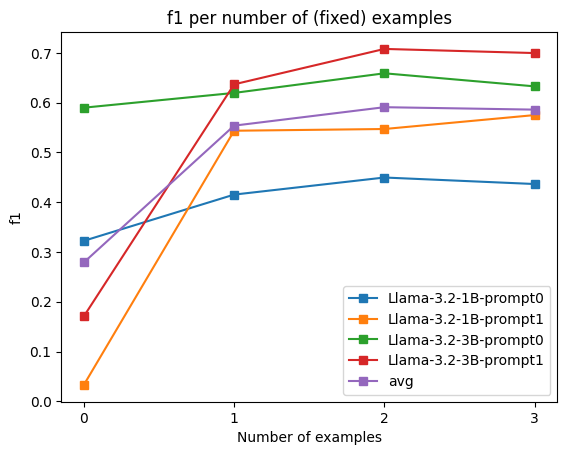

In [25]:
metric_per_shot = pd.DataFrame()

def get_n_shots(config_name):
    parts = config_name.split("-")
    for i, part in enumerate(parts):
        if part.endswith("shot"):
            return int("".join(c for c in part if c.isdigit())), "-".join(parts[:i])
    return None, None

for config in model_configs:
    config_name = config["name"]
    n_shots, model_name = get_n_shots(config_name)
    if n_shots is not None:
        config_prefix = model_name
        metric_per_shot.at[n_shots, config_prefix] = model_statistics_nshots.at[config_name, metric]
metric_per_shot["avg"] = metric_per_shot.mean(axis=1)
metric_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

In [20]:
metric_per_column = pd.DataFrame(index=model_statistics.index, columns=COLS_TO_PREDICT)
metric_per_column_per_shot = pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics.index, metric_per_shot.index]),
    columns=COLS_TO_PREDICT
)
for col in COLS_TO_PREDICT:
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        n_shots, model_name = get_n_shots(config)
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            metric_per_column.at[config, col] = value
            if n_shots is not None:
                metric_per_column_per_shot.at[(model_name, n_shots), col] = value
        else:
            metric_per_column.at[config, col] = pd.NA
print(f"Per-column {metric} scores:")
metric_per_column

Per-column f1 scores:


,HouseNumber,StreetName,City,State,Country
libpostal,0.75,0.604651,0.432432,0.444444,0.428571
libpostal-expanded,0.7,0.238095,0.525253,0.333333,0.584615
deepparse-bpemb,0.704225,0.036036,0.289593,0.0,0.12
deepparse-fasttext,0.625,0.081633,0.393013,0.0,0.233333
deepparse-bpemb-attention,0.130435,0.021978,0.011765,0.0,0.176991
deepparse-fasttext-attention,0.392857,0.014184,0.11828,0.0,0.226415
Llama-3.2-1B-prompt0-0shot,0.246377,0.269006,0.488263,0.142857,0.0
Llama-3.2-1B-prompt1-0shot,0.0,0.040816,0.015625,0.166667,0.081633
Llama-3.2-3B-prompt0-0shot,0.631579,0.637363,0.6,0.30303,0.578313
Llama-3.2-3B-prompt1-0shot,0.185185,0.081633,0.179104,0.0,0.24


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

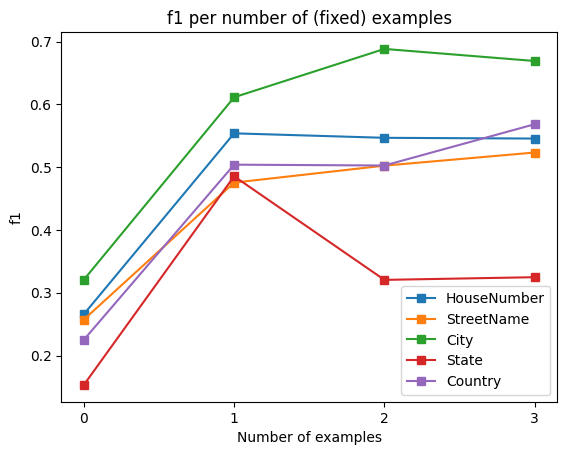

In [21]:
metric_per_column_per_shot = metric_per_column_per_shot.groupby(level=1).mean()
metric_per_column_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

In [22]:
bzk_fields = bzkopen_val["field"].unique()
print(f"bzk_fields: {bzk_fields}")
metric_per_bzk_field = pd.DataFrame(index=model_statistics.index, columns=bzk_fields)
metric_per_bzk_field_per_shot =  pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics.index, metric_per_shot.index]),
    columns=bzk_fields
)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        value = compare_preds(preds[mask], subset, target_columns=COLS_TO_PREDICT)[metric]
        metric_per_bzk_field.at[config, field] = value
        n_shots, model_name = get_n_shots(config)
        if n_shots is not None:
            metric_per_bzk_field_per_shot.at[(model_name, n_shots), field] = value
print(f"Per-BZK-field {metric} scores:")
metric_per_bzk_field

bzk_fields: <ArrowStringArray>
['ApplicantCurrentAddress',        'VictimBirthPlace',
     'ApplicantBirthPlace',        'VictimDeathPlace']
Length: 4, dtype: str
Per-BZK-field f1 scores:


,ApplicantCurrentAddress,VictimBirthPlace,ApplicantBirthPlace,VictimDeathPlace
libpostal,0.528,0.526316,0.542373,0.4
libpostal-expanded,0.416988,0.55814,0.640625,0.888889
deepparse-bpemb,0.220532,0.425532,0.304348,0.4
deepparse-fasttext,0.265683,0.666667,0.380282,0.363636
deepparse-bpemb-attention,0.0625,0.064516,0.09901,0.0
deepparse-fasttext-attention,0.14094,0.208333,0.130435,0.0
Llama-3.2-1B-prompt0-0shot,0.43686,0.236842,0.2,0.111111
Llama-3.2-1B-prompt1-0shot,0.023256,0.05,0.045455,0.0
Llama-3.2-3B-prompt0-0shot,0.637584,0.4,0.554054,0.727273
Llama-3.2-3B-prompt1-0shot,0.166667,0.285714,0.117647,0.4


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

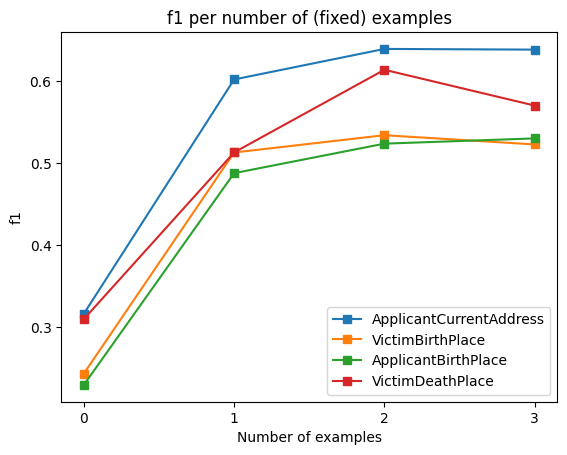

In [23]:
metric_per_bzk_field_per_shot = metric_per_bzk_field_per_shot.groupby(level=1).mean()
metric_per_bzk_field_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)